#makemore hurrayyyy

##task 1

1. Karpathy'nin İngilizce names.txt dosyasıyla başla, Türkçe veri görev 5'te gelecek. Bigram'ları önce Python dictionary ile, sonra 27x27 torch tensor'da say. Tabloyu videodaki gibi görselleştir. (3:03 - 24:02)

In [161]:
words = open('names.txt','r').read().splitlines()

# lol nicki lazim o yuzden kaggledan falan bir dataset bulup kendime bir nick urettirecegim

In [162]:
len(words)


32033

In [163]:
b = {} # dictionary / hash map olusuturp frekanslarini aliyoruz
for w in words:
  chs = ['<S>'] + list(w) + ['<E>'] # modele bitis ve baslangic tokenlarini vermek icin lazim
  for ch1,ch2 in zip(chs,chs[1:]):
    bigram = (ch1,ch2)
    b[bigram] = b.get(bigram,0)+1 # eger ki boyle bir key yoksa valueyu 0dan baslatmasi icin

In [164]:
sorted(b.items(),key = lambda kv: -kv[1]) # key degil de valueya gore siralamak icin

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [165]:
#bunu 2d matrixe cevirelim simdi frekans mapine
import torch

N = torch.zeros((27,27),dtype=torch.int32) # ingilizcede 26 harf var + baslangic ve bitis tokeni ile 28x28 matrix oluyor


In [166]:
#int32 type matrix olusturdugumuz icin charlarda kullanabilecegimiz bir lookup tablea ihtiyacimiz var
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()} #reverse mapping, plot icin lazim oluyor

In [167]:
b = {} # dictionary / hash map olusuturp frekanslarini aliyoruz
for w in words:
  chs = ['.'] + list(w) + ['.'] # modele bitis ve baslangic tokenlarini vermek icin lazim
  for ch1,ch2 in zip(chs,chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1,ix2] += 1

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

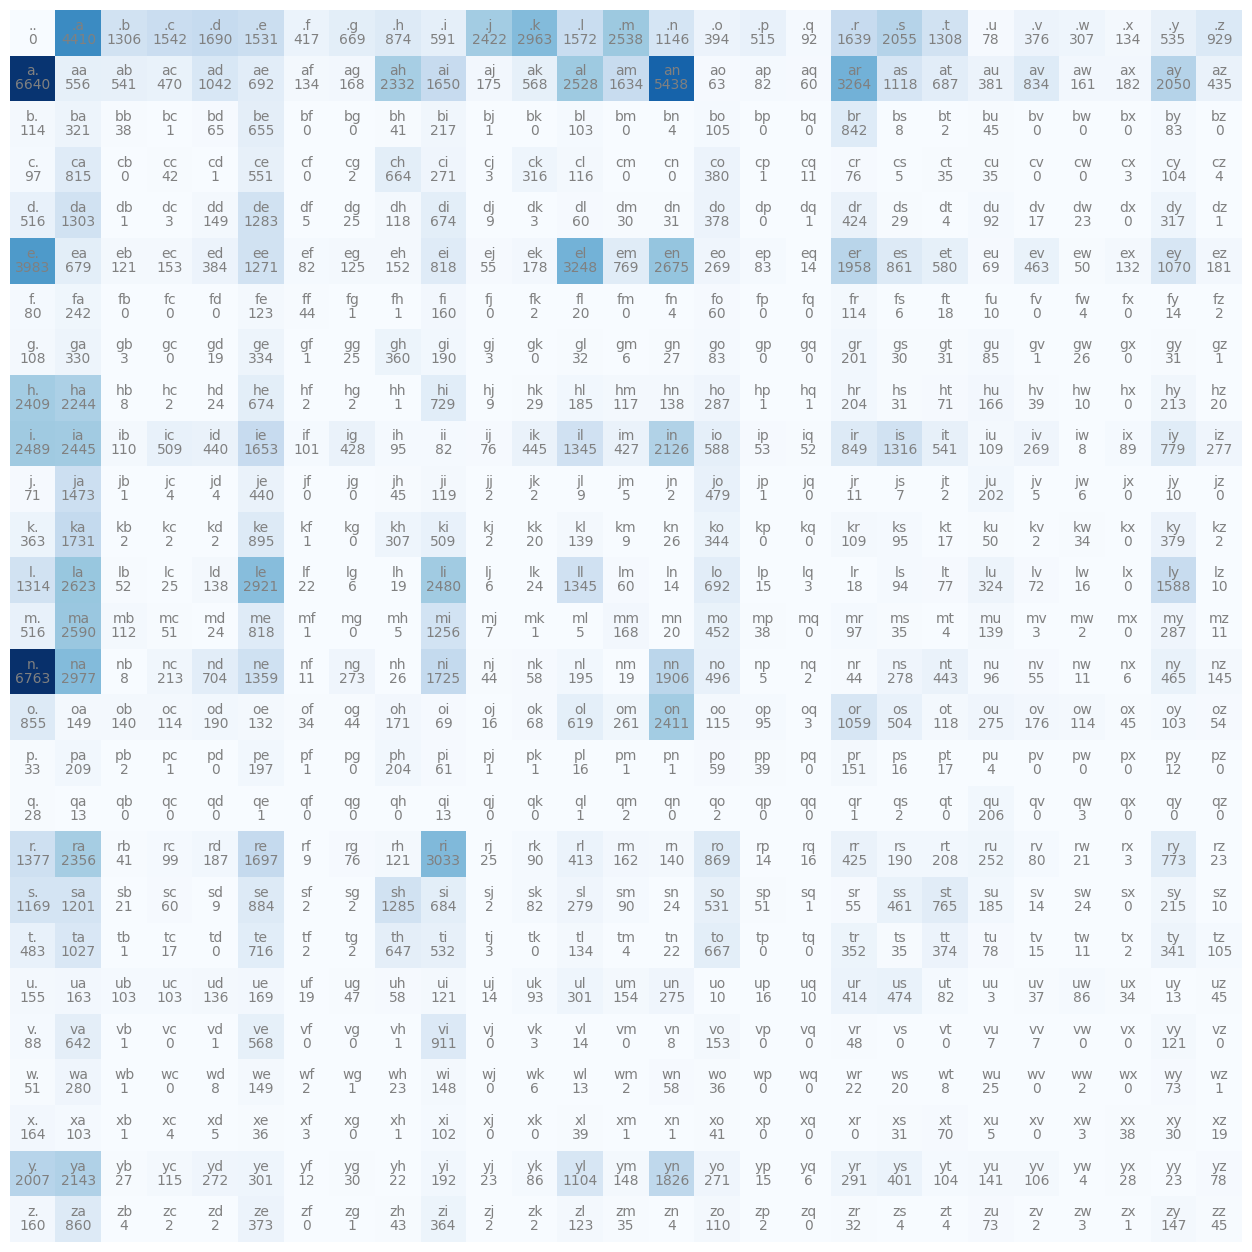

In [168]:


import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center",va=  "top" , color='gray')
plt.axis('off') # 1. Sutun biten harfleri gosterirken 1. satir baslayan harfleri gosteriyor

In [169]:
# not: start ve ending tokeni '.' ile degistirdik cunku frekans tablosunda 'A<S>' ve '<E>A'gibi anlamsiz bigramlar cikti

## task 2
2. Sayım tablosunu satır satır olasılıklara çevir ve modelden yeni isimler örnekle. Broadcasting'e dikkat: videodaki keepdim tuzağı, sessizce yanlış model üreten cinsten. (24:02 - 50:14)

In [170]:
g = torch.Generator().manual_seed(2147483647) # lokal seed vermek icin generator kullandik
# obur turlu .manual_seed kullansak global scopeta olur init ve dropoutu da etkiler
p = torch.rand(3,generator=g)
p = p / p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [171]:
torch.multinomial(p,num_samples=100,replacement=True,generator=g) # orneklem cekiyor

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])

In [172]:
p = N[0].float() # sadece ilk satirin olasilik dagilimini yapiyoruz
p = p / p.sum() # olasiliklarin toplami 1e esit
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [173]:
torch.multinomial(p,num_samples=1,replacement=True,generator=g) # orneklem cekiyor

tensor([6])

In [174]:
P = (N+1).float() # model smoothing icin N+X x ne kadar buyukse o kadar uniformed diste donusuyor
P = P/P.sum(1,keepdim=True) # 27,27 matrix / 27,1 matrix (bu nasil mumkun oluyor?)
# cevap: broadcasting semantics
# also note: keepdims parametresi broadcasting yonunu belirliyor sutundan satira mi yoksa satirdan sutuna mi copy edilecegini yani
P.shape

torch.Size([27, 27])

In [175]:
g = torch.Generator().manual_seed(2147483647)
for i in range(10):
  ix = 0
  generated = []
  while True:
    p = P[ix]
    # p = torch.ones(27)/27.0  // uniform distrubition yani untrained model ifade ediyor
    ix = torch.multinomial(p,num_samples=1,replacement=True,generator=g).item() # orneklem cekiyor
    generated.append(itos[ix])
    if ix == 0:
      break
  print(''.join(generated))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


## task 3
3. Negative log likelihood'u hesapla. Smoothing için sahte sayım ekle. Neden log, neden negatif, neden ortalama: bunu teslim videonda kendi cümlelerinle anlatacaksın. (50:14 - 1:02:57)

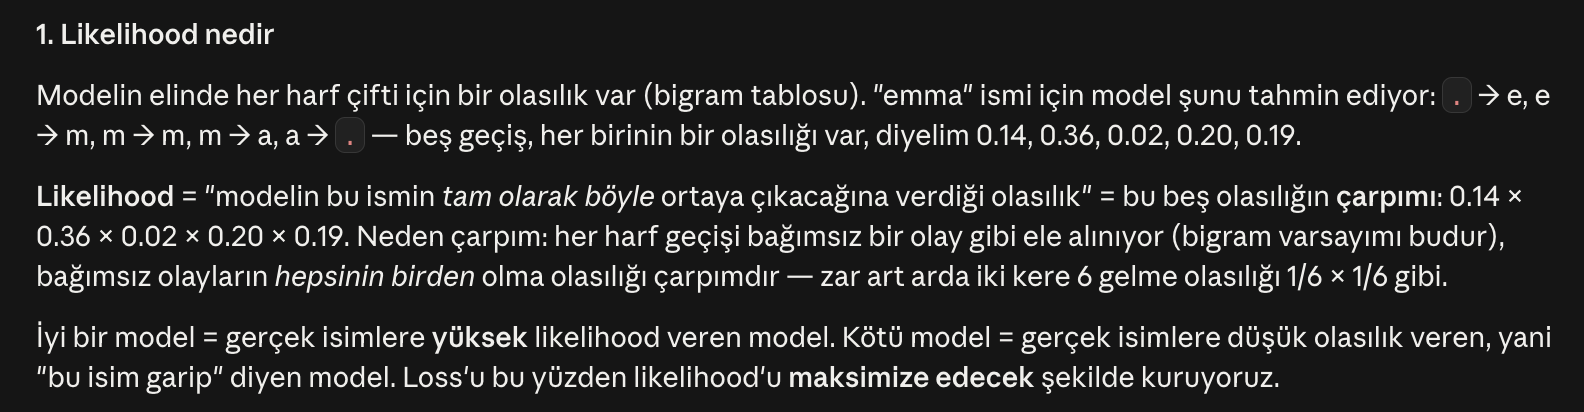

In [176]:
#not: herhangi bir likelihood yerine log almamizin sebebi calistigimiz sayilarin aslinda birer olasilik olmasi
# olasiliklar 0 ile 1 arasinda oldugundan dolayi birden fazla sayinin carpimi 1e10 gibi cok kucuk sayilara
# goturur bizi. cozum olarak log aldigimizda bu carpimi bir toplamaya cevirebiliyoruz ornegin:
# log(a*b*c) = log(a) + log(b) + log(c)
# log 0 ile 1 arasi daima monoton ve negatif oldugundan dolayi negatifini alabiliyoruz
# monoton azalan oldugundan dolayi bize bir cost function veriyor, BUNU GD ile optimize ediyoruz

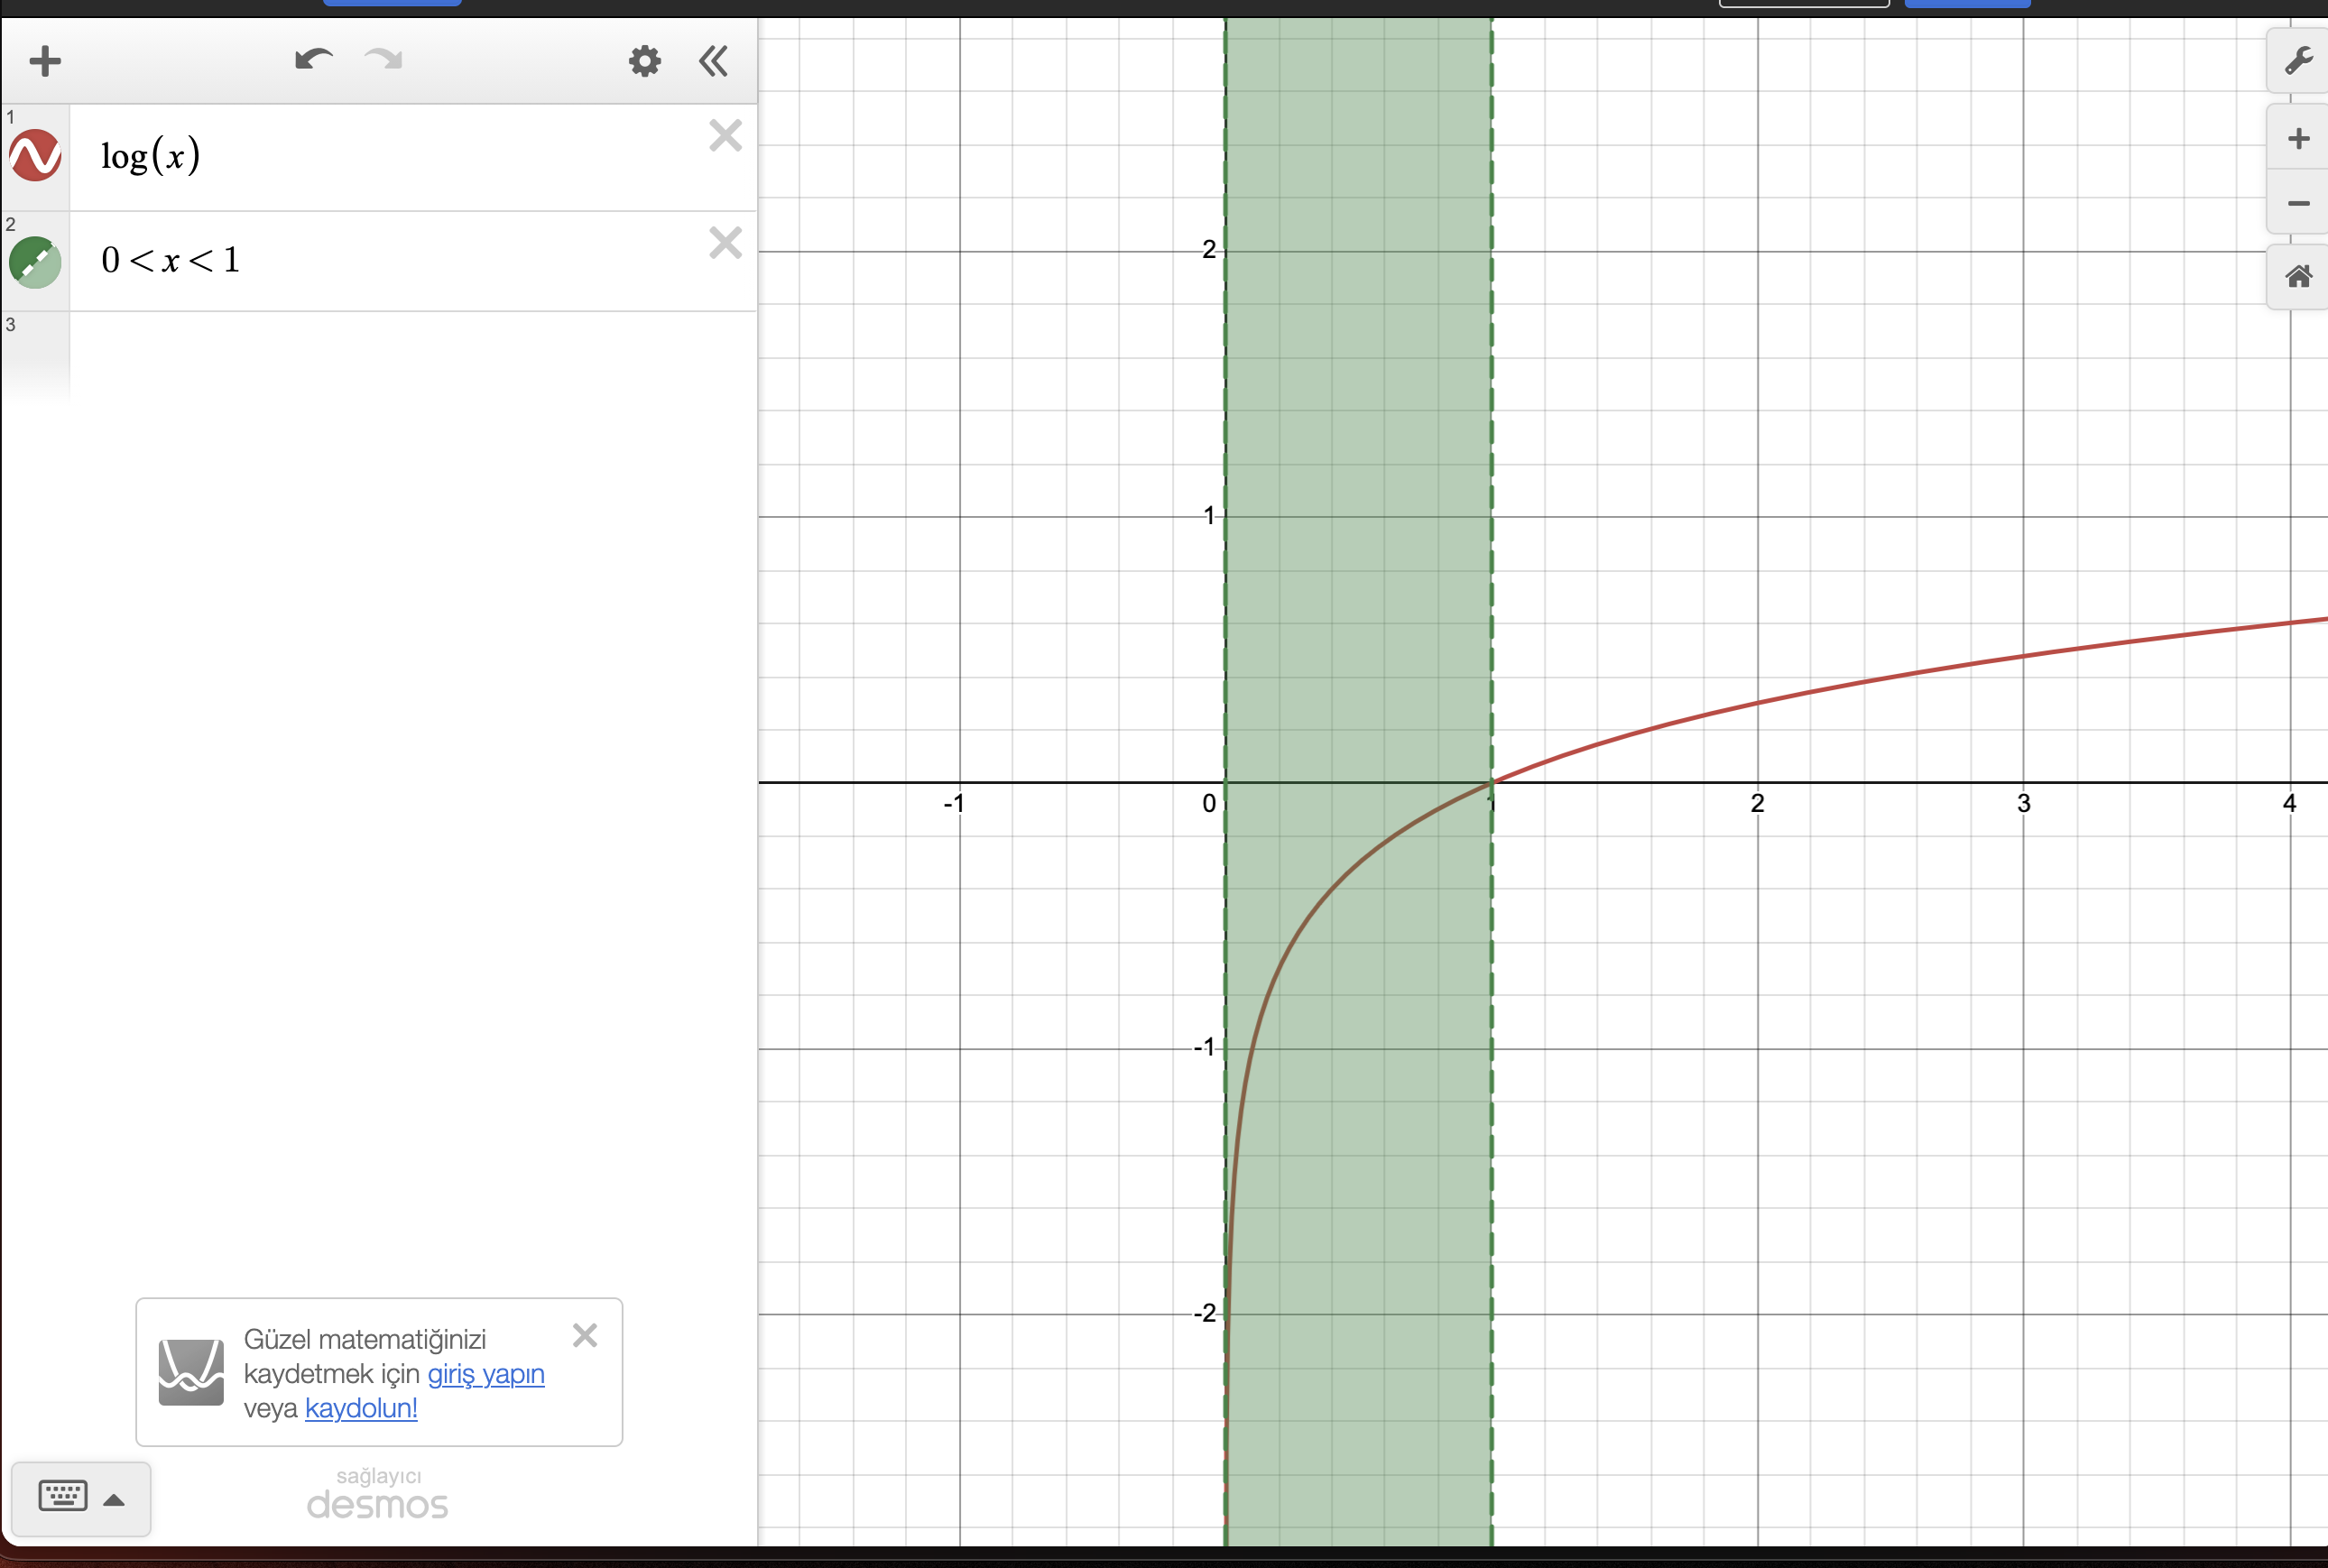

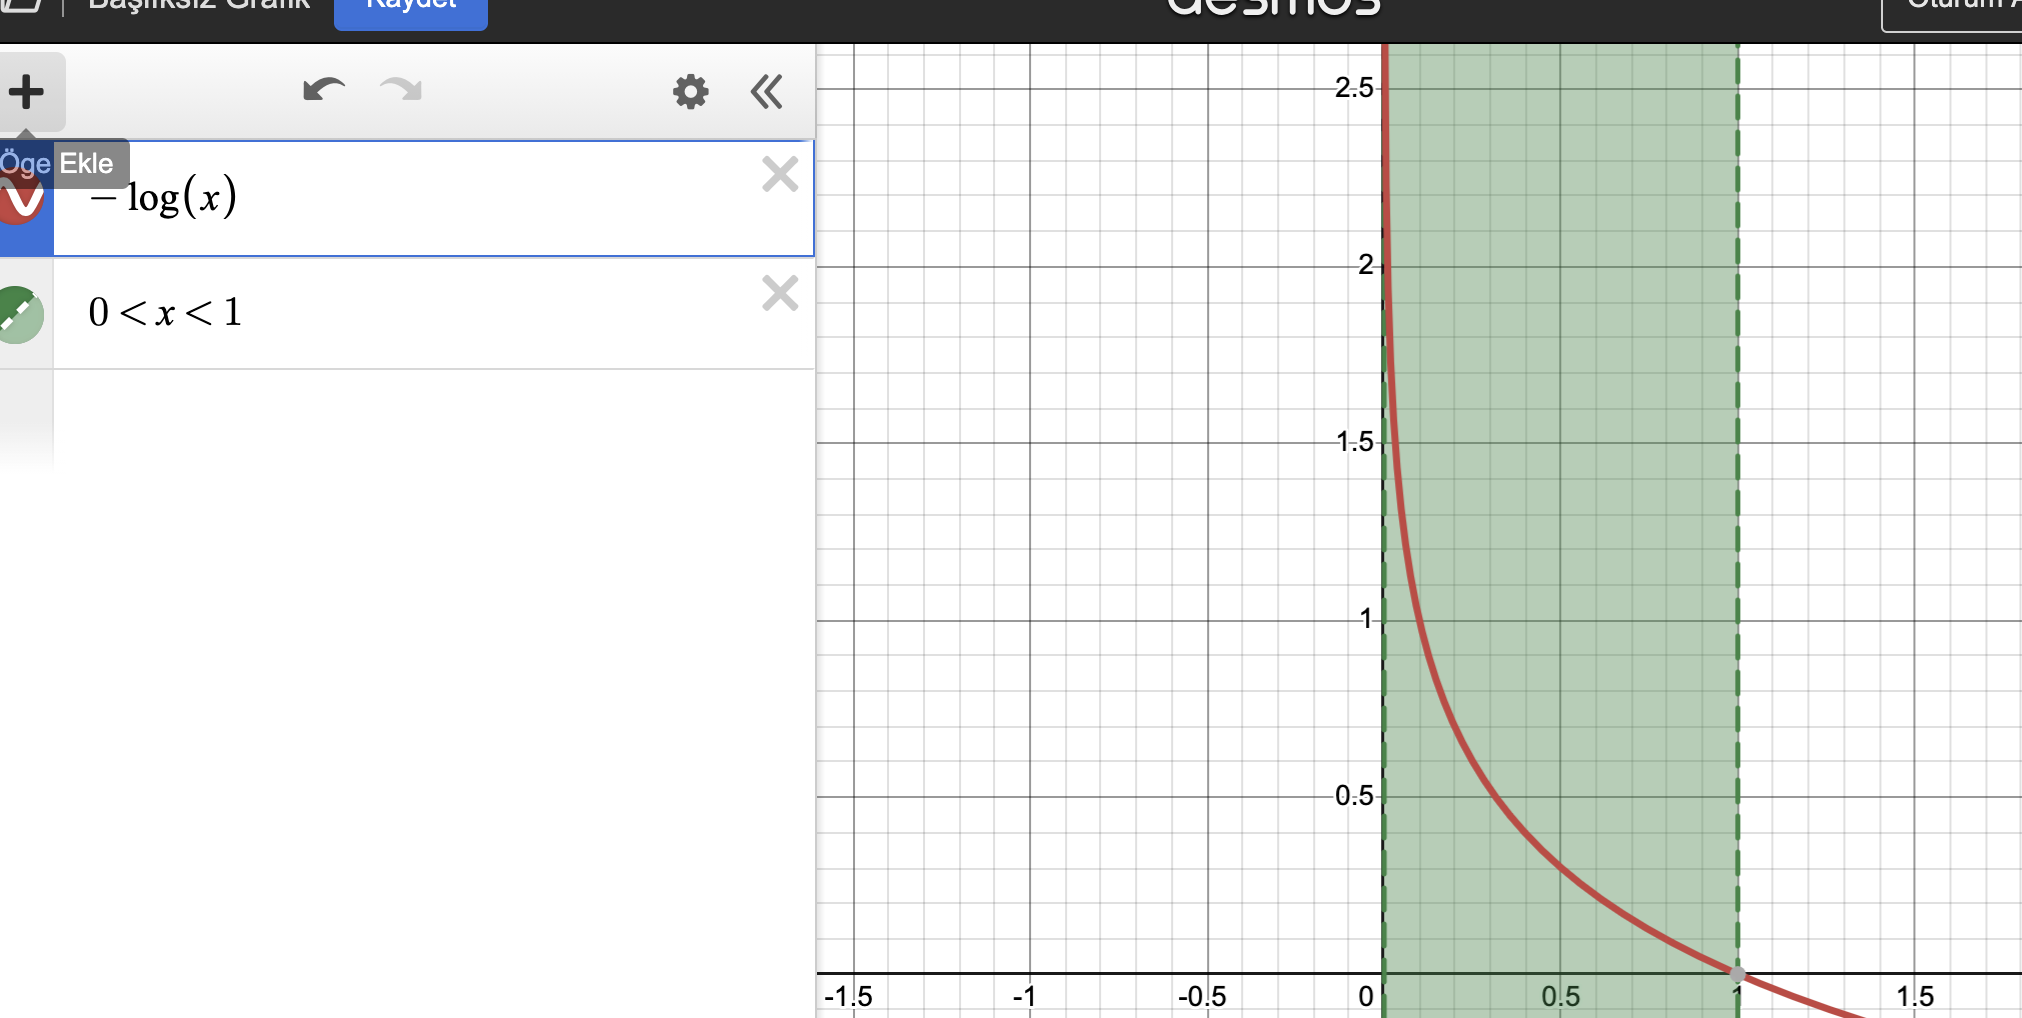

In [177]:
# KRITIK: NEDEN MSE gibi bir loss function kullanmadik da NLL kullandik?
# cunku MSE verinin bir normal dagilimdan geldigini varsayar.
# bizim yaptigimiz dagilim surekli olmayip kategorik oldugundan (gauss icin sart) MSE gibi loss func kullanamiyoruz

In [178]:
#kritik bir not daha: avg almamizin sebebi ise kelimeler uzadikca
#log likelihood daha yuksek cikiyor dogal olarak. Bunu onlemek icin her bir kelimenin
# log likelihoodunu harf sayisina bolunce daha reasonable bir sonuc cikiyor

In [179]:
log_likelihood = 0.0
n = 0
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1,ch2 in zip(chs,chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1,ix2]
    log_prob = torch.log(prob)
    log_likelihood += log_prob
    n+=1

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}') # avg neg log likelihood

log_likelihood=tensor(-559951.5625)
nll=tensor(559951.5625)
2.4543561935424805


##task 4
4. Aynı modeli tek katmanlı sinir ağıyla kur: one-hot input, 27x27 weight matrix, softmax, NLL loss, gradient descent döngüsü. Loss'un görev 3'teki sayım modelinin loss'una yaklaştığını göster. Buradaki backward() geçen hafta micrograd'da kendi yazdığın mekanizmanın aynısı. (1:02:57 - 1:54:31)




In [180]:
# simdi elimizde bir loss function var. Bunu optimize etmek icin bir neural network yapisina ihtiyacimiz var

In [181]:
# create the training set of bigrams (x,y)
xs, ys = [],[]
for w in words[:1]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs,chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1) # bir harf bir harf tahmin edecegi icin (daha dogrusu one hot encoding)
    ys.append(ix2)


xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()

# modelin genel yapisi bir harf tahmin ediyor. Obur harfi tahmin ediyor. Obur harfi tahmin ediyor.....
# kelimeyi tahmin ettikten sonra loss hesaplaniyor. gradient descent ile parametre optimizasyonu yapiliyor

In [182]:
# one hot encoding yapmamizin sebebi charlari integer olarak ifade etmemizin bir anlami olmuyor cunku o integer degeri bir
# sayiyi ifade etmiyor bir 'kategoriyi' ifade ediyor. Bunun icin 27 input norondan ilgili sayiya denk gelen harfi turn on/off seklinde
# one hot encode etmemiz icap ediyor.

In [183]:
import torch.nn.functional as F
xenc = F.one_hot(xs,num_classes=27).float() # agirliklari float olacagi icin typecasting lazim
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

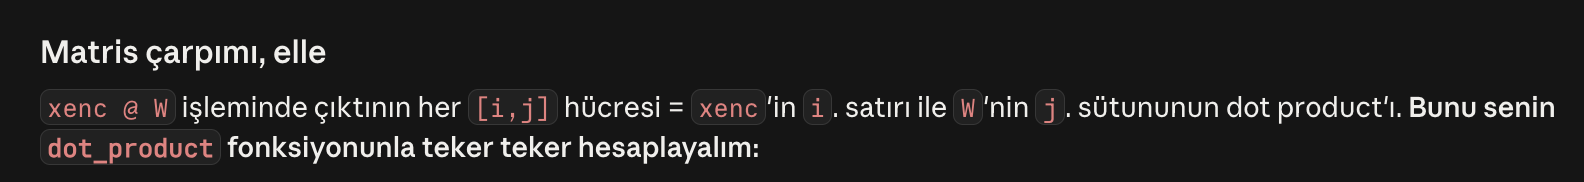

In [184]:
W = torch.randn([27,27],generator=g,requires_grad=True) # sadece 1 layer olacak ve 27 output layer olacagi icin
# bunu kuantum/lineer cebir mantigi ile de yorumlayabiliriz:
# matrix carpimi aslinda bir uzayi dondurme/egip bukme islemini yapiyor
# matrixin icerisindeki random parametreler GDye girerek en uygun uzay bulunuyor inputlar icin


In [185]:
# simdi geldik zurnanin zirt dedigi yere:


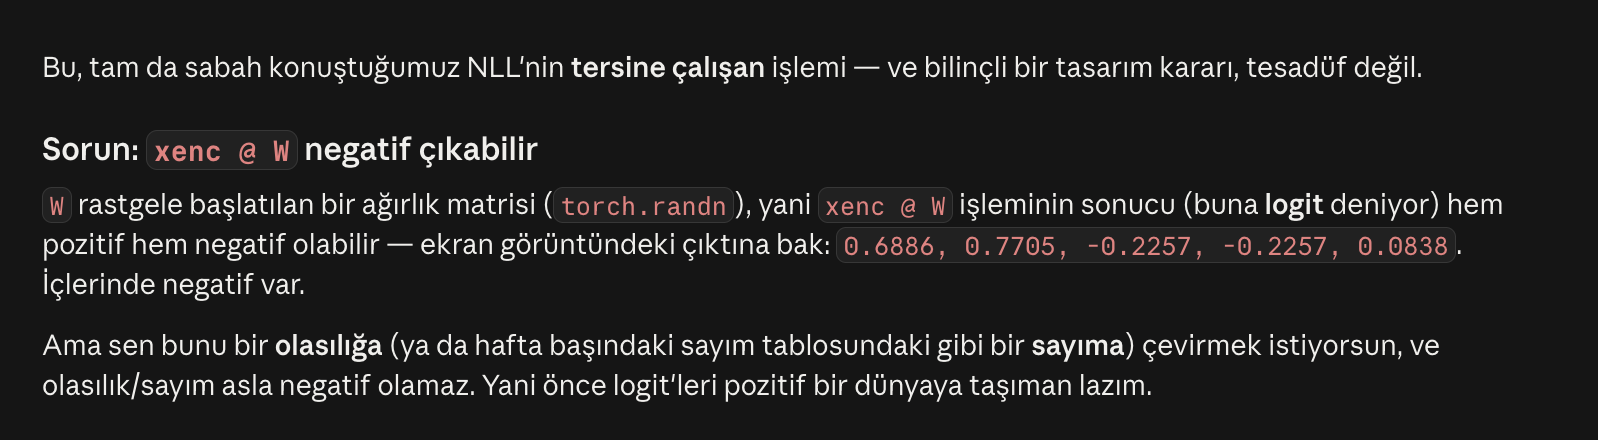

In [186]:
#NLL ile loss hesaplayacagimiz icin NLLe bir toplamlari 1 olan bir
# olasilik dagilimi vermek istiyoruz

# Bunun icin de xenc @ W ciktisini normalize etmemiz gerekiyor.
# abs veya kare alma yerine exp kullanmak istiyoruz cunku yon ve buyukluk bilgisini koruyor.
# ayni zamanda logun tersi.

In [187]:
#forward pass
logits = xenc @ W # bu cikti negatif olabilir o yuzden normalize ediyoruz
counts = logits.exp() # normalize islemi. Elimizde cikti olarak pozitif bir matrix oluyor
probs = counts/counts.sum(1,keepdims= True) # Olasilik dagilimina donusutruoyru
loss = -probs[torch.arange(5),ys].log().mean() # avg negative log likelihood

In [188]:
# COOOOOK ONEMLI NOT:
# SON 2 SATIR ASLINDA SOFTMAX FONKSIYONUNUN TA KENDISI!!!!



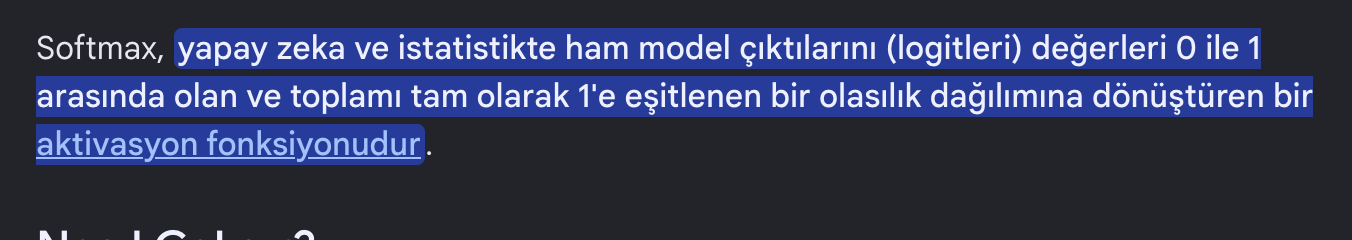

In [189]:
probs[0].sum() # her satir toplami 1 ayni yukaridaki gibi

tensor(1., grad_fn=<SumBackward0>)

In [190]:
# backward pass
W.grad = None # her epochta farkli bir cost landscapede calistigimiz icin
loss.backward()

In [191]:
W.data+= -0.1 * W.grad

In [192]:
#=========================#hepsi bir arada

In [193]:
# create the training set of bigrams (x,y)
xs, ys = [],[]
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs,chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1) # bir harf bir harf tahmin edecegi icin (daha dogrusu one hot encoding)
    ys.append(ix2)


xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g, requires_grad=True)

In [194]:
# hepsi bir arada
# gradient descent
for k in range(100):
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log() . mean ()
  print(loss.item())
  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()
  # update
  W.data += -50 * W.grad

3.758953809738159
3.371100425720215
3.1540427207946777
3.020373582839966
2.927711009979248
2.8604023456573486
2.8097288608551025
2.7701022624969482
2.7380728721618652
2.711496591567993
2.6890032291412354
2.6696884632110596
2.65293025970459
2.638277769088745
2.6253879070281982
2.613990545272827
2.60386323928833
2.5948219299316406
2.5867116451263428
2.5794036388397217
2.572789192199707
2.5667762756347656
2.5612878799438477
2.5562586784362793
2.551633596420288
2.547365665435791
2.543415069580078
2.5397486686706543
2.536336660385132
2.5331544876098633
2.5301804542541504
2.5273969173431396
2.5247862339019775
2.522334337234497
2.520028829574585
2.517857789993286
2.515810966491699
2.513878345489502
2.512052059173584
2.5103237628936768
2.5086872577667236
2.5071349143981934
2.5056614875793457
2.5042612552642822
2.5029289722442627
2.5016608238220215
2.5004520416259766
2.4992988109588623
2.498197317123413
2.4971446990966797
2.4961376190185547
2.495173692703247
2.4942493438720703
2.493363380432129

## task 5
5. İnternetten bir Türkçe isim listesi bul (açık kaynak listeler var, GitHub'da arayabilirsin) ve iki modeli de bu veriyle tekrar koştur. Alfabeyi Türkçe karakterlerle genişlet (ç, ğ, ı, ö, ş, ü). Modelin ürettiği isimlerden örnekleri ve loss'u göster.

In [195]:
kelimeler = open('turkce_isimler.txt','r').read().splitlines()

In [196]:
len(kelimeler)


3096

In [197]:
harita = {} # dictionary / hash map olusuturp frekanslarini aliyoruz
for w in kelimeler:
  chs = ['.'] + list(w) + ['.'] # modele bitis ve baslangic tokenlarini vermek icin lazim
  for ch1,ch2 in zip(chs,chs[1:]):
    bigram = (ch1,ch2)
    harita[bigram] = harita.get(bigram,0)+1 # eger ki boyle bir key yoksa valueyu 0dan baslatmasi icin

In [198]:
sorted(harita.items(),key = lambda kv: -kv[1]) # key degil de valueya gore siralamak icin

[(('n', '.'), 655),
 (('.', 'k'), 494),
 (('a', 'n'), 469),
 (('.', 'a'), 442),
 (('k', '.'), 406),
 (('k', 'a'), 399),
 (('a', 'r'), 393),
 (('.', 'b'), 391),
 (('.', 't'), 359),
 (('a', 'y'), 334),
 (('a', '.'), 296),
 (('b', 'a'), 277),
 (('r', '.'), 276),
 (('a', 'k'), 254),
 (('a', 'l'), 249),
 (('t', 'a'), 249),
 (('u', 'r'), 216),
 (('t', 'u'), 215),
 (('.', 'y'), 207),
 (('.', 's'), 204),
 (('u', 'n'), 198),
 (('r', 'a'), 196),
 (('y', 'a'), 188),
 (('k', 'u'), 188),
 (('e', 'r'), 187),
 (('e', 'n'), 181),
 (('l', 'a'), 176),
 (('u', 'l'), 165),
 (('ş', '.'), 160),
 (('.', 'ç'), 160),
 (('a', 't'), 154),
 (('u', '.'), 143),
 (('e', '.'), 141),
 (('ç', 'a'), 141),
 (('i', 'n'), 136),
 (('u', 'k'), 136),
 (('ı', 'n'), 134),
 (('ğ', 'a'), 129),
 (('a', 'ğ'), 127),
 (('l', '.'), 126),
 (('ı', '.'), 124),
 (('n', 'g'), 124),
 (('.', 'e'), 123),
 (('b', 'e'), 122),
 (('e', 'k'), 122),
 (('t', '.'), 121),
 (('l', 'u'), 119),
 (('s', 'a'), 115),
 (('u', 't'), 114),
 (('k', 'ı'), 114),


In [202]:
K = torch.zeros((30,30),dtype=torch.int32) # turkce alfabede 29 +1

In [205]:
#int32 type matrix olusturdugumuz icin charlarda kullanabilecegimiz bir lookup tablea ihtiyacimiz var
chars = sorted(list(set(''.join(kelimeler))))
stoi2 = {s:i+1 for i,s in enumerate(chars)}
stoi2['.'] = 0
itos2 = {i:s for s,i in stoi2.items()} #reverse mapping, plot icin lazim oluyor
itos2

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'r',
 18: 's',
 19: 't',
 20: 'u',
 21: 'v',
 22: 'y',
 23: 'z',
 24: 'ç',
 25: 'ö',
 26: 'ü',
 27: 'ğ',
 28: 'ı',
 29: 'ş',
 0: '.'}

In [206]:
harita = {} # dictionary / hash map olusuturp frekanslarini aliyoruz
for w in kelimeler:
  chs = ['.'] + list(w) + ['.'] # modele bitis ve baslangic tokenlarini vermek icin lazim
  for ch1,ch2 in zip(chs,chs[1:]):
    ix1 = stoi2[ch1]
    ix2 = stoi2[ch2]
    K[ix1,ix2] += 1

(np.float64(-0.5), np.float64(29.5), np.float64(29.5), np.float64(-0.5))

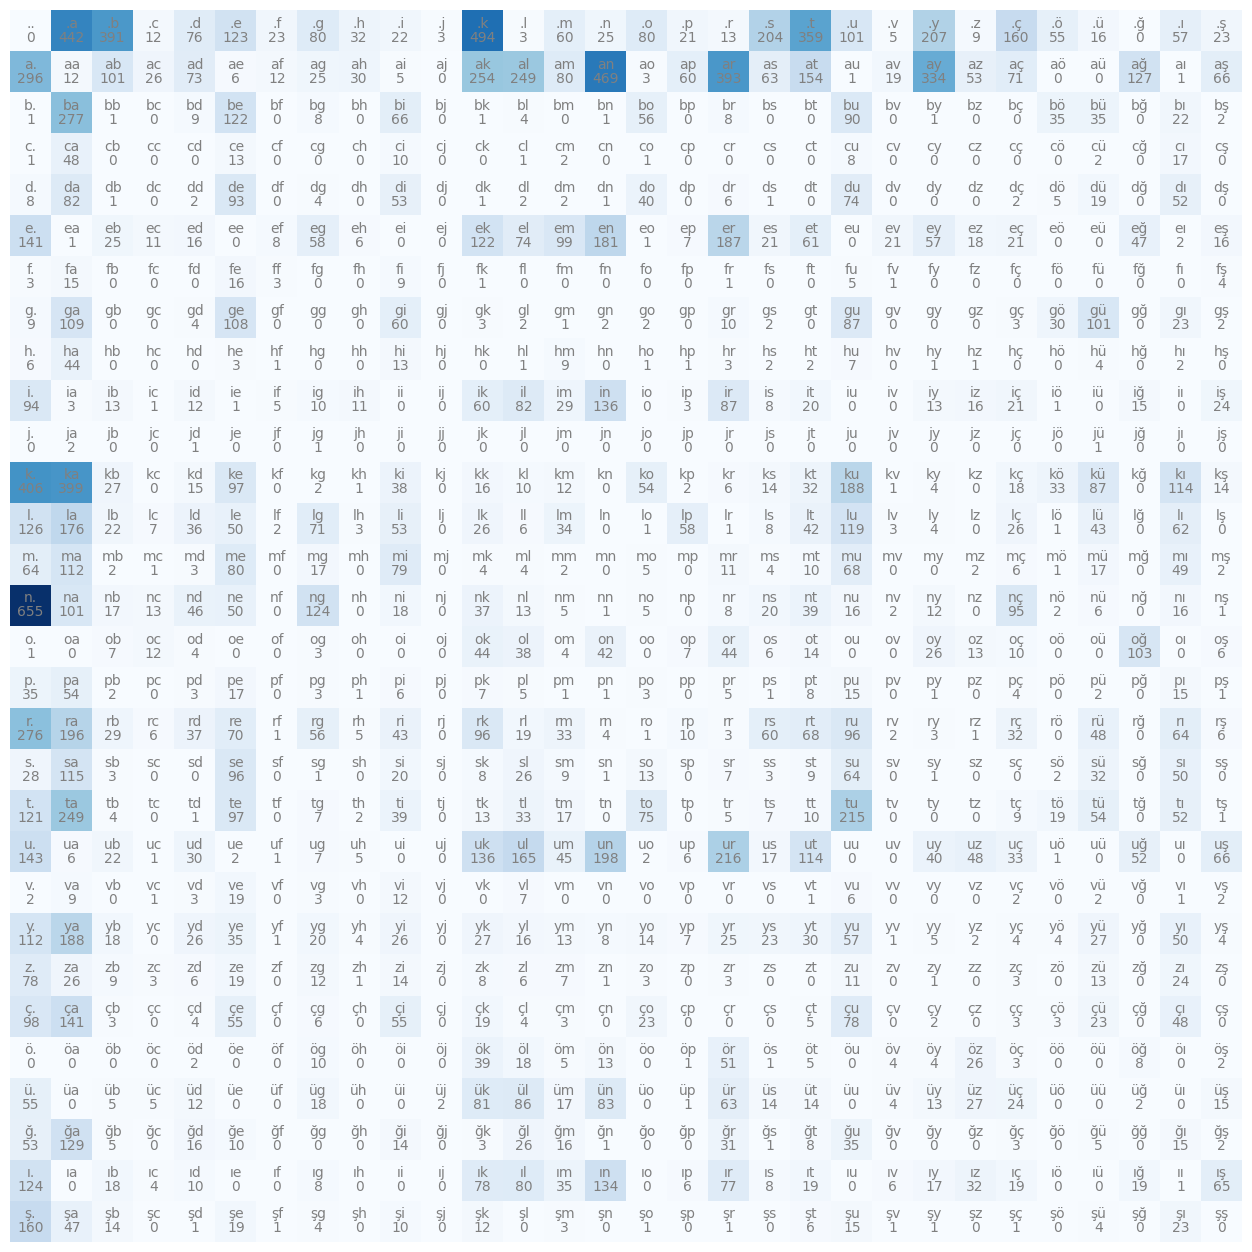

In [209]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(16,16))
plt.imshow(K, cmap='Blues')
for i in range(30):
    for j in range(30):
        chstr = itos2[i] + itos2[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, K[i, j].item(), ha="center",va=  "top" , color='gray')
plt.axis('off') # 1. Sutun biten harfleri gosterirken 1. satir baslayan harfleri gosteriyor

In [210]:
P = (K+1).float() # model smoothing icin N+X x ne kadar buyukse o kadar uniformed diste donusuyor
P = P/P.sum(1,keepdim=True) # 27,27 matrix / 27,1 matrix (bu nasil mumkun oluyor?)
# cevap: broadcasting semantics
# also note: keepdims parametresi broadcasting yonunu belirliyor sutundan satira mi yoksa satirdan sutuna mi copy edilecegini yani
P.shape

torch.Size([30, 30])

In [211]:
g = torch.Generator().manual_seed(2147483647)
for i in range(10):
  ix = 0
  generated = []
  while True:
    p = P[ix]
    # p = torch.ones(27)/27.0  // uniform distrubition yani untrained model ifade ediyor
    ix = torch.multinomial(p,num_samples=1,replacement=True,generator=g).item() # orneklem cekiyor
    generated.append(itos2[ix])
    if ix == 0:
      break
  print(''.join(generated))

unsrançmokslbör.
e.
çerdış.
tmur.
baçulgüze.
tu.
çimengiyşbersa.
h.
at.
ürsayeç.


In [212]:
log_likelihood = 0.0
n = 0
for w in kelimeler:
  chs = ['.'] + list(w) + ['.']
  for ch1,ch2 in zip(chs,chs[1:]):
    ix1 = stoi2[ch1]
    ix2 = stoi2[ch2]
    prob = P[ix1,ix2]
    log_prob = torch.log(prob)
    log_likelihood += log_prob
    n+=1

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}') # avg neg log likelihood

log_likelihood=tensor(-56249.1875)
nll=tensor(56249.1875)
2.4549028873443604


In [218]:
# create the training set of bigrams (x,y)
xs, ys = [],[]
for w in kelimeler:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs,chs[1:]):
    ix1 = stoi2[ch1]
    ix2 = stoi2[ch2]
    xs.append(ix1) # bir harf bir harf tahmin edecegi icin (daha dogrusu one hot encoding)
    ys.append(ix2)


xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((30,30), generator=g, requires_grad=True)

In [219]:
# hepsi bir arada
# gradient descent
for k in range(100):
  # forward pass
  xenc = F.one_hot(xs, num_classes=30).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log() . mean ()
  print(loss.item())
  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()
  # update
  W.data += -50 * W.grad

4.003251075744629
3.5999341011047363
3.3371806144714355
3.165470600128174
3.0502941608428955
2.965991258621216
2.9010605812072754
2.8495395183563232
2.8076584339141846
2.7728872299194336
2.743508815765381
2.7183408737182617
2.6965529918670654
2.677546739578247
2.6608731746673584
2.646184206008911
2.6331980228424072
2.621680974960327
2.61143159866333
2.602278232574463
2.594071626663208
2.586682081222534
2.5799992084503174
2.5739264488220215
2.5683841705322266
2.5633041858673096
2.5586283206939697
2.554309368133545
2.550306558609009
2.5465853214263916
2.543116569519043
2.5398757457733154
2.5368406772613525
2.5339927673339844
2.5313150882720947
2.5287938117980957
2.5264153480529785
2.524168014526367
2.522040843963623
2.5200254917144775
2.5181124210357666
2.5162947177886963
2.514564037322998
2.5129151344299316
2.5113413333892822
2.509838104248047
2.5083999633789062
2.5070228576660156
2.5057027339935303
2.5044360160827637
2.5032191276550293
2.502049207687378
2.5009233951568604
2.49983930587

## BONUSS


In [ ]:
# su siralar lol oynadigim icin kendime nick urettim:

In [220]:
words = open('lol_nickler.txt','r').read().splitlines()

In [221]:
#int32 type matrix olusturdugumuz icin charlarda kullanabilecegimiz bir lookup tablea ihtiyacimiz var
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()} #reverse mapping, plot icin lazim oluyor

In [222]:
#bunu 2d matrixe cevirelim simdi frekans mapine
import torch

N = torch.zeros((27,27),dtype=torch.int32) # ingilizcede 26 harf var + baslangic ve bitis tokeni ile 28x28 matrix oluyor


In [223]:
b = {} # dictionary / hash map olusuturp frekanslarini aliyoruz
for w in words:
  chs = ['.'] + list(w) + ['.'] # modele bitis ve baslangic tokenlarini vermek icin lazim
  for ch1,ch2 in zip(chs,chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1,ix2] += 1

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

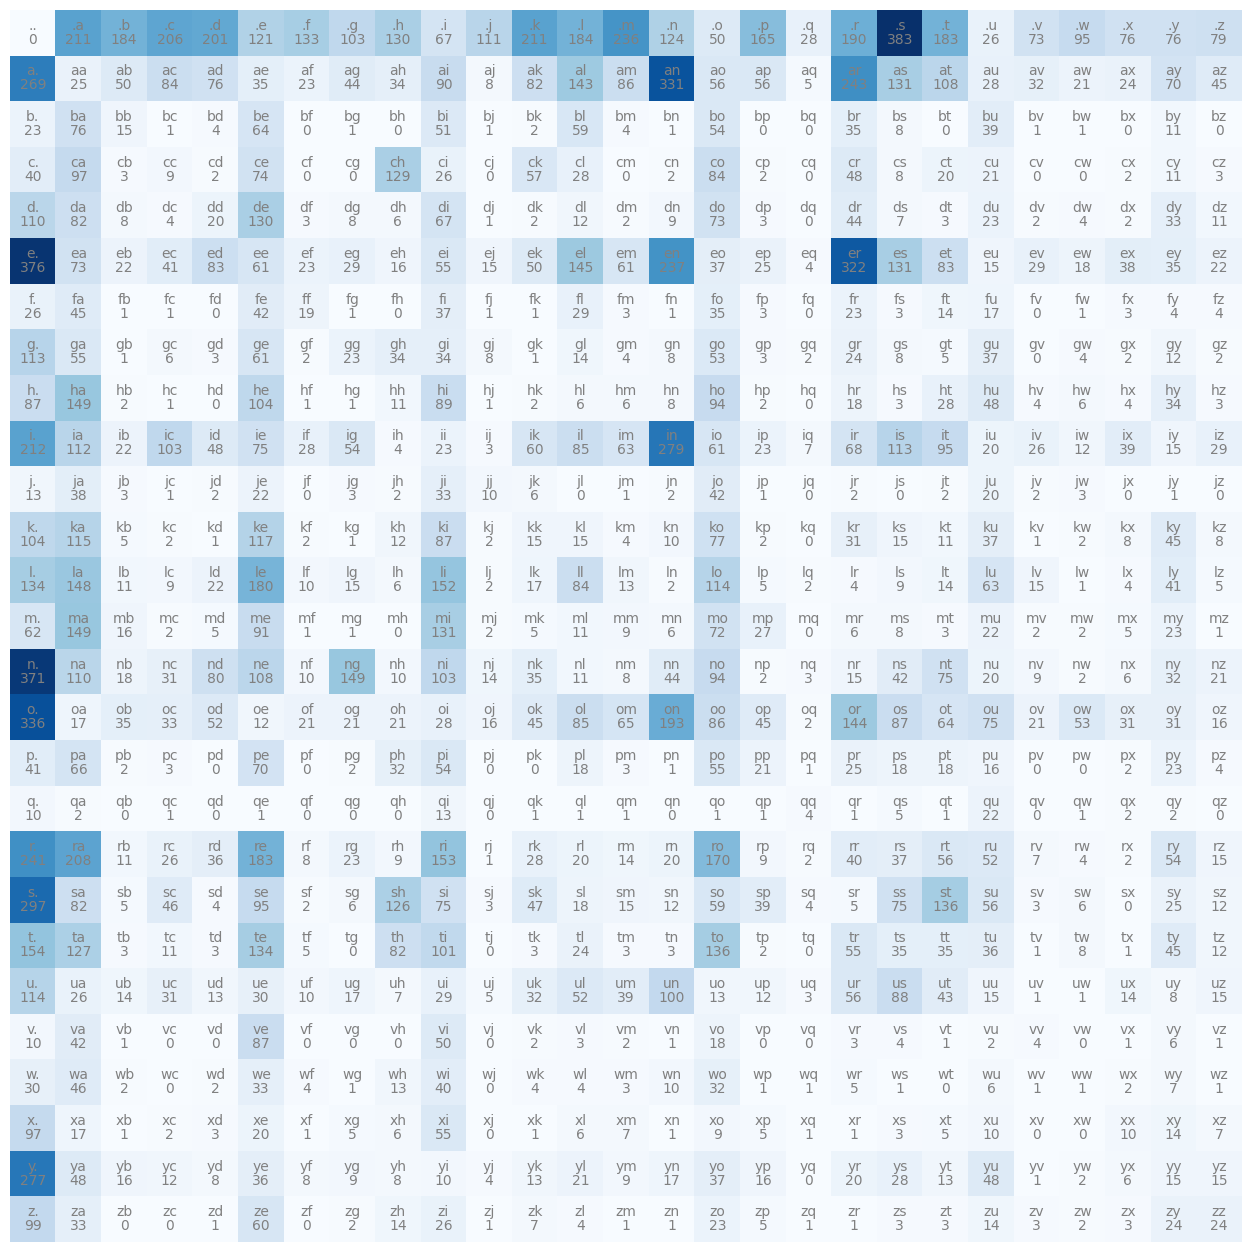

In [224]:


import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center",va=  "top" , color='gray')
plt.axis('off') # 1. Sutun biten harfleri gosterirken 1. satir baslayan harfleri gosteriyor

In [226]:
P = (N+1).float() # model smoothing icin N+X x ne kadar buyukse o kadar uniformed diste donusuyor
P = P/P.sum(1,keepdim=True) # 27,27 matrix / 27,1 matrix (bu nasil mumkun oluyor?)
# cevap: broadcasting semantics
# also note: keepdims parametresi broadcasting yonunu belirliyor sutundan satira mi yoksa satirdan sutuna mi copy edilecegini yani
P.shape

torch.Size([27, 27])

In [242]:
g = torch.Generator().manual_seed(3169)
for i in range(1000):
  ix = 0
  generated = []
  while True:
    p = P[ix]
    # p = torch.ones(27)/27.0  // uniform distrubition yani untrained model ifade ediyor
    ix = torch.multinomial(p,num_samples=1,replacement=True,generator=g).item() # orneklem cekiyor
    generated.append(itos[ix])
    if ix == 0:
      break
  print(''.join(generated))

gogunoran.
nbeitsaridpeve.
m.
urteonggangh.
s.
aou.
my.
lguml.
nanor.
mra.
ttz.
rse.
jelchtrenedar.
ddypetiflgolathas.
ktamy.
d.
iaupiclariv.
ttor.
nmiorzazainacaokiohs.
skindspaneth.
xj.
sckuxhoo.
key.
ke.
ho.
ous.
riamanngou.
eerixyd.
wa.
u.
megrichobrr.
y.
htouuftibiprodyucakennsapran.
tn.
sthin.
d.
nky.
kico.
p.
rg.
ge.
s.
fferivipeyun.
hersinin.
aiboren.
ma.
va.
ktararresurere.
hun.
riannketoanothanencyuun.
fey.
rar.
llexays.
lceiskorthenl.
omane.
riner.
kice.
x.
x.
nk.
ngxeahin.
r.
bn.
bghaxy.
z.
g.
cacetyranamowi.
anncoramaoocai.
alxixid.
sla.
r.
ch.
sttustoidiosthay.
y.
vebiaricla.
bakereley.
boiz.
ptourcino.
ainongoe.
mozei.
moostosahrro.
cobotesini.
strtshiwesn.
fker.
yen.
humaky.
pocaredyaahep.
mpreseermi.
lehra.
ancas.
pesan.
dadoveje.
kzadositene.
wae.
coslicikren.
noth.
z.
leot.
dawanfankridt.
zze.
sshyusen.
kk.
ki.
po.
amesvr.
ans.
mi.
s.
ciquyitu.
zr.
plarew.
kose.
lbolamteak.
ckutaliaca.
ybuzhwi.
ro.
scxetebarsurdano.
sthon.
jan.
gark.
gooxspyto.
e.
mabrddekhosschwulus